In [17]:
import pandas as pd

kmer_df = pd.read_csv("../data/tlimmuno2_13mer.csv")
kmer_df = kmer_df.drop(columns=["Unnamed: 0", "sequence"])

In [18]:
# read 12k_binders.fa into a csv
df = pd.read_csv("../data/master_data_12k.csv")
df = df[["global_id", "sequence"]]

# for each sequence, make a set of all 13-mers
def get_kmers(seq, k=13):
    return set(seq[i:i+k] for i in range(len(seq) - k + 1))
df["13mers"] = df["sequence"].apply(get_kmers)

In [19]:
# 1) collapse kmer_df to one row per pep (across HLA alleles)
pep_stats = (
    kmer_df
    .groupby("pep")
    .agg(
        pep_max_prediction=("prediction", "max"),   # max across 7 HLA
        pep_mean_prediction=("prediction", "mean"), # mean across 7 HLA
        pep_min_rank=("Rank", "min"),               # change to "min" if lower rank is better
        pep_mean_rank=("Rank", "mean"),
    )
)

# 2) expand df so each kmer is its own row
#    assuming df has a column "13mers" that is a list/set of kmers
df_expanded = df.explode("13mers")

# 3) attach per-pep stats to each kmer
df_expanded = df_expanded.join(pep_stats, on="13mers")

# 4) aggregate back to the original row index over that row's set of kmers
kmer_stats = (
    df_expanded
    .groupby(level=0)
    .agg(
        max_prediction=("pep_max_prediction", "max"),
        min_rank=("pep_min_rank", "min"),          # or "min" if that makes more sense
        mean_prediction=("pep_mean_prediction", "mean"),
        mean_rank=("pep_mean_rank", "mean"),
    )
)

# 5) join back to df
df = df.join(kmer_stats)

In [20]:
# precompute best HLA and Rank per kmer (pep)
kmer_best = (
    kmer_df.sort_values("Rank")
           .drop_duplicates("pep", keep="first")
           .set_index("pep")   # index is the kmer
)

rank_lookup = kmer_best["Rank"].to_dict()
hla_lookup  = kmer_best["HLA"].to_dict()

def get_best_kmer_info(row):
    best_kmer = None
    best_hla = None
    best_rank = float("inf")
    
    for kmer in row["13mers"]:
        rank = rank_lookup.get(kmer)
        if rank is not None and rank < best_rank:
            best_rank = rank
            best_kmer = kmer
            best_hla = hla_lookup[kmer]
    
    return pd.Series({
        "best_kmer": best_kmer,
        "best_hla": best_hla,
        "best_rank": best_rank
    })

# result = df.iloc.apply(get_best_kmer_info, axis=1)
df[["best_kmer", "best_hla", "best_rank"]] = df.apply(get_best_kmer_info, axis=1)

In [21]:
df["best_kmer"].describe()

count             12000
unique             8717
top       GASINSAMVGALG
freq                304
Name: best_kmer, dtype: object

In [25]:
print(len(df[df["min_rank"] < 0.02]))

10173


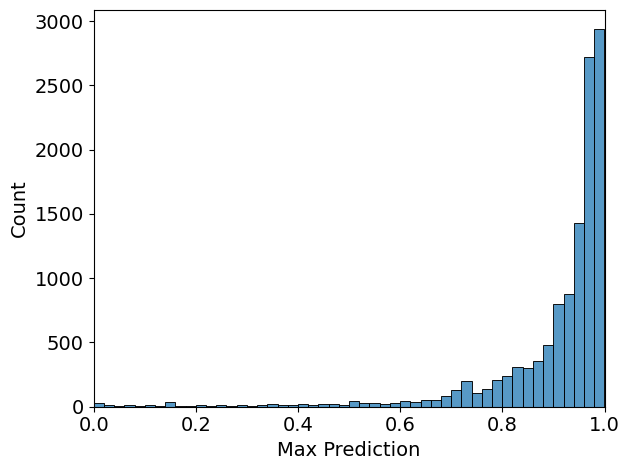

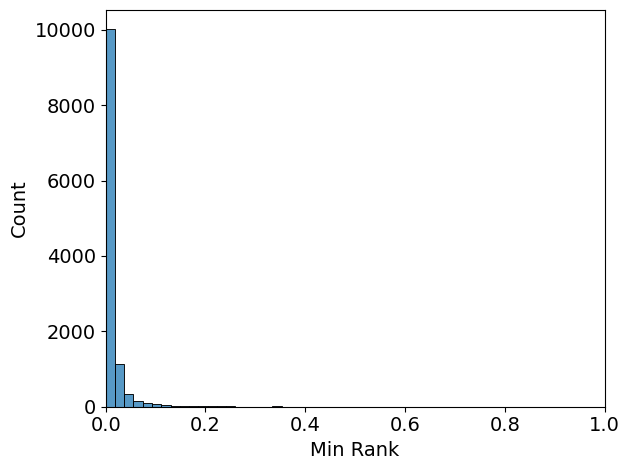

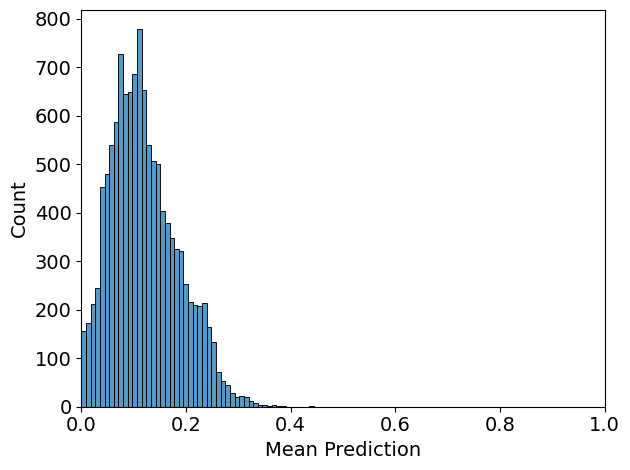

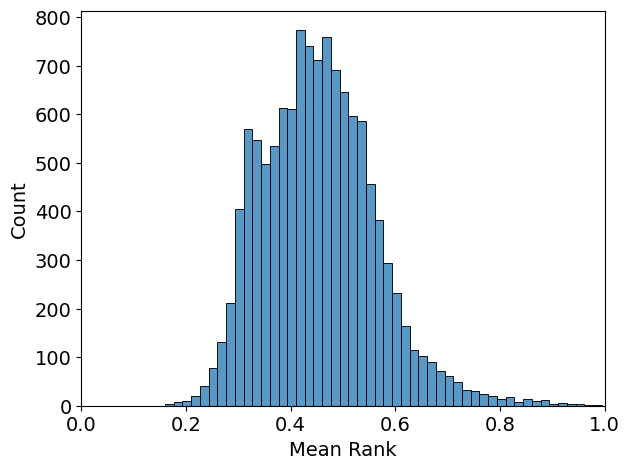

In [22]:
# plot distribution of each one
import matplotlib.pyplot as plt
import seaborn as sns
for col in kmer_stats.columns:
    plt.figure()
    sns.histplot(df[col], bins=50)
    # kde plot instead
    # sns.kdeplot(df[col], fill=True)
    plt.xlabel(col.replace("_", " ").title(), fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim(0,1)
    plt.tight_layout()
    plt.savefig(f"../results/tlimmuno2/tlimmuno2_{col}.png", dpi=300)

In [23]:
df.to_csv("../data/tlimmuno2_13mer_stats.csv", index=False)